# 03 · Microstructure stage 1: do absorption, rejection and order-book events carry exit information?

**Question.** After the chento and squeeze_bull arms the user asked: *"isn't time simply just statistical overfitting?
... I still feel there is something in absorption, rejection and liquidity that could help to define exits better."*
Before building exits from those ideas, this stage measures whether the events carry information at all. At the first
event inside a trade, is the rest of the trade worth less than at matched moments without the event?

Frozen rules: [PREREGISTRATION_MICROSTRUCTURE.md](PREREGISTRATION_MICROSTRUCTURE.md). Write-up:
[findings_microstructure.md](findings_microstructure.md). This notebook recomputes every walk, event, placebo and
statistic from the frozen code and the checksum-verified data, checks them against the saved run, and shows the evidence.
**Verdict: NONE PROMOTED.**

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION_MICROSTRUCTURE.md").exists(), "execute from studies/notebooks/exit_policy_2026_09"
sys.path.insert(0, str(STUDY)); sys.path.insert(0, str(STUDY.parent / "orb_study"))
import micro_lib as M, micro_run as R
from review_plots import AXIS, INK2, SERIES, style
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
RES = M.RESULTS
F0, PRE, REP, V, ERA = (json.loads((RES / f).read_text()) for f in
                        ("freeze_F0.json", "preconditions.json", "report.json", "verdict.json", "exploratory_era_matched.json"))
changed = [f for f, h in F0["files"].items() if M.sha256(M.ROOT / f) != h]
print("F0", F0["created_utc"], "| frozen files unchanged:", not changed, "| inputs unchanged:", R.input_hashes() == F0["inputs_sha256"])
print("verdict:", V["verdict"], "written", V["created_utc"], "| decision family:", ", ".join(F0["family"]))

F0 2026-09-15T15:41:36+00:00 | frozen files unchanged: True | inputs unchanged: True
verdict: NONE PROMOTED written 2026-09-15T15:41:54+00:00 | decision family: chento:E1_against, chento:E2_rejection, chento:E3_against


## 1. The run is reproducible

Every trade is walked again on the 1-minute perp path, every event found again, every placebo and statistic recomputed.
The result must equal `events.csv.gz` and the classifications in `verdict.json`.

In [2]:
_, series, pops = R.load_all()
events, report = R.compute_outcomes(series, pops, F0["family"])
saved = pd.read_csv(RES / "events.csv.gz")
num = ["elapsed_min", "bin", "controls", "controls_time_only", "cv", "cv_notime", "placebo", "placebo_notime",
       "placebo_time_only", "delta"]
same = (events[["pop", "kind", "tid"]].astype(str).equals(saved[["pop", "kind", "tid"]].astype(str))
        and all(np.allclose(events[c].to_numpy(float), saved[c].to_numpy(float), rtol=0, atol=1e-9, equal_nan=True) for c in num))
same_class = {k: t["classification"] for k, t in report["tests"].items() if t["primary"]} == V["classifications"]
print("events identical:", same, "| classifications identical:", same_class, "| event rows:", len(events))
pd.DataFrame({p: {"trades": len(tr), "assets": ", ".join(sorted(tr["asset"].unique())), "first entry": tr["entry_day"].min(),
                  "last entry": tr["entry_day"].max(), "median minutes in trade": int((tr["x"] - tr["i0"]).median()),
                  "exit mix (1-minute walk)": tr["kind"].value_counts().to_dict()} for p, tr in pops.items()}).T

events identical: True | classifications identical: True | event rows: 711


,trades,assets,first entry,last entry,median minutes in trade,exit mix (1-minute walk)
chento,392,"BTC, ETH",2021-04-17,2026-08-22,2815,"{'stop': 194, 'time': 159, 'target': 39}"
squeeze_bull,122,BTC,2022-03-25,2026-09-04,1260,"{'target': 49, 'stop': 43, 'time': 30}"
short_squeeze,71,BTC,2022-05-06,2026-05-18,65,"{'stop': 42, 'target': 19, 'time': 10}"


## 2. Preconditions (all passed before the freeze)

- **Inputs and identity.** Inputs matched their hashes, and every book file matched its published checksum; five
  archive days do not exist and stay missing. The three populations are exactly the earlier phases' trades, and every
  entry equals the perp close.
- **Walker.** The 1-minute walker reproduces squeeze_bull's S0 walks exactly, chento's 15-minute exit kinds on all 392
  trades, and the short_squeeze replay (spot path) on 68 of 71.
- **Fixtures and coverage.** 23 fixtures pass. The book covers 97.6–99.2 % of in-trade minutes.
- **Causality.** Masking the future changed no feature or event at ten cut points.

In [3]:
display(pd.DataFrame({m: {"pass": PRE[m]["pass"]} for m in ("M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8")}).T)
m4 = PRE["M4"]
print("walker: squeeze_bull S0", m4["squeeze_bull_equal_to_S0"], "| chento agreement", round(m4["chento_kind_agreement"]["share"], 3),
      "| short_squeeze agreement", round(m4["short_squeeze_kind_agreement"]["share"], 3))
display(pd.DataFrame(m4["short_squeeze_kind_agreement"]["differences"]))
display(pd.DataFrame(PRE["M6"]["in_trade"]).T)
pd.DataFrame(PRE["M7"]["cuts"]).drop(columns="cut_minute")

,pass
M1,True
M2,True
M3,True
M4,True
M5,True
M6,True
M7,True
M8,True


walker: squeeze_bull S0 {'equal': 122, 'trades': 122} | chento agreement 1.0 | short_squeeze agreement 0.958


,tid,kind,replay_exit_reason
0,BTC:1662191100,stop,time
1,BTC:1695634200,stop,target
2,BTC:1770723000,stop,target


,eligible_trades,minutes,share_with_snapshot,e3_testable
chento,290,763456,0.975748,True
squeeze_bull,111,174876,0.989936,True
short_squeeze,50,6209,0.991947,True


,asset,cut_utc,open_trades_at_cut,feature_differences,event_differences
0,BTC,2024-12-18T02:43:00+00:00,2,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
1,BTC,2026-05-07T03:54:00+00:00,4,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
2,BTC,2024-02-13T14:11:00+00:00,3,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
3,BTC,2023-06-22T14:13:00+00:00,5,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
4,BTC,2026-05-06T10:45:00+00:00,1,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
5,ETH,2026-06-17T04:11:00+00:00,2,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
6,ETH,2023-04-06T11:17:00+00:00,1,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
7,ETH,2025-04-08T19:07:00+00:00,1,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
8,ETH,2025-11-23T07:05:00+00:00,5,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0
9,ETH,2025-11-22T06:45:00+00:00,6,"{'z_flow': 0, 'dp5': 0, 'zq': 0}",0


## 3. How often the events happen inside trades

This decided what could be tested: a decision test needed 30 event trades, each with at least 3 matched controls. Only
chento's absorption, rejection and book tests reached it. short_squeeze trades last a median of 65 minutes and almost
never meet these events. squeeze_bull meets them on 4–21 % of trades. The events are rare by construction: absorbed
buying (E1 against a long) holds in about one BTC minute in 5,500.

,population,event,eligible,with event,share,median hours to first,event minutes per 24 h in trade,included (>= 3 controls),MDE 80 % (R),decision family
0,chento,E1_against,392,122,0.311,12.983,0.437,119,0.406,True
1,chento,E2_rejection,392,219,0.559,7.850,0.302,215,0.302,True
2,chento,E3_against,290,51,0.176,17.167,2.814,48,0.639,True
3,chento,E4_at_level,392,27,0.069,19.917,0.052,27,0.852,False
4,chento,E1_supportive,392,71,0.181,18.000,0.283,70,0.529,None
5,chento,E2_acceptance,392,35,0.089,7.783,0.048,35,0.749,None
6,chento,E3_supportive,290,75,0.259,18.900,4.072,75,0.511,None
7,squeeze_bull,E1_against,122,15,0.123,9.383,0.251,15,0.556,False
8,squeeze_bull,E2_rejection,122,26,0.213,16.450,0.198,26,0.422,False
9,squeeze_bull,E3_against,111,12,0.108,15.817,9.848,12,0.621,False


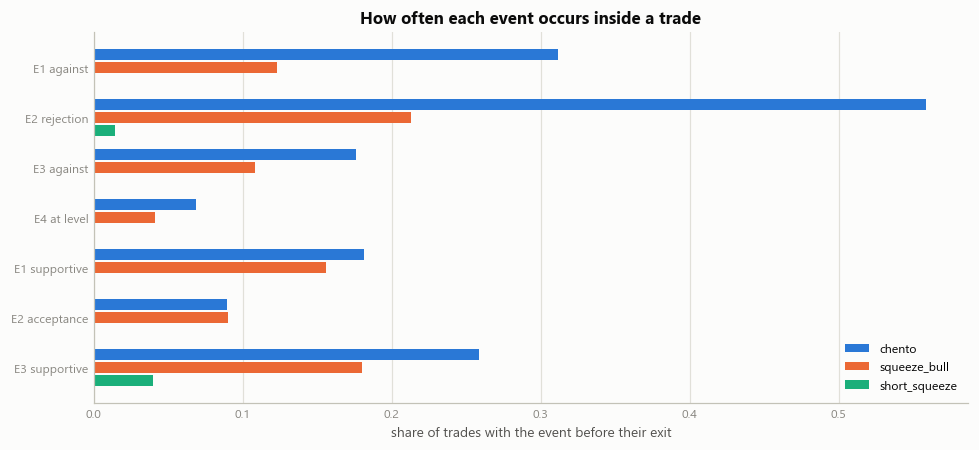

all BTC minutes: |z| >= 3 buy side 0.90 %, sell side 0.94 %; E1 against (long) 0.018 %; E1 supportive (long) 0.027 %


In [4]:
rows = []
for p, v in PRE["M8"]["populations"].items():
    for k, t in v["tests"].items():
        rows.append({"population": p, "event": k, "eligible": t["eligible_trades"], "with event": t["trades_with_event"],
                     "share": t["share_with_event"], "median hours to first": t["median_elapsed_hours"],
                     "event minutes per 24 h in trade": t["event_minutes_per_24h_in_trade"],
                     "included (>= 3 controls)": t["included_with_min_controls"], "MDE 80 % (R)": t["mde80_R"],
                     "decision family": t.get("in_family")})
C = pd.DataFrame(rows)
display(C.round(3))
kinds = list(M.KINDS)
fig, ax = plt.subplots(figsize=(9, 4.2))
width = 0.26
yk = np.arange(len(kinds))
for j, p in enumerate(M.POPULATIONS):
    share = [C[(C.population == p) & (C.event == k)]["share"].iat[0] for k in kinds]
    ax.barh(yk + (j - 1) * width, share, height=width - 0.04, color=SERIES[j], label=p)
ax.set_yticks(yk); ax.set_yticklabels([k.replace("_", " ") for k in kinds]); ax.invert_yaxis()
style(ax, grid_axis="x"); ax.set_xlabel("share of trades with the event before their exit")
ax.legend(loc="lower right"); ax.set_title("How often each event occurs inside a trade")
plt.tight_layout(); plt.show()
b = series["BTC"]
fin = np.isfinite(b.z_flow)
with np.errstate(invalid="ignore"):
    print("all BTC minutes: |z| >= 3 buy side %.2f %%, sell side %.2f %%; E1 against (long) %.3f %%; E1 supportive (long) %.3f %%" % (
        100 * (b.z_flow[fin] >= 3).mean(), 100 * (b.z_flow[fin] <= -3).mean(),
        100 * ((b.z_flow >= 3) & (b.dp5 <= 0))[fin].mean(), 100 * ((b.z_flow <= -3) & (b.dp5 >= 0))[fin].mean()))

## 4. The test: the rest of the trade after the first event, against matched moments

Δ = continuation value at the first event minus the placebo. The continuation value is the move from that minute to the
shipped exit, in R. The placebo is the same quantity for other trades matched on four things: the same point in their
life (±5 % of the horizon), the same 0.25 R profit bin, the same direction, and no event yet and no calendar overlap.
Negative Δ means the event came before worse-than-matched continuation. Intervals: 30-day block bootstrap of entry
days. Filled markers are the pre-registered decision family, open markers are descriptive.

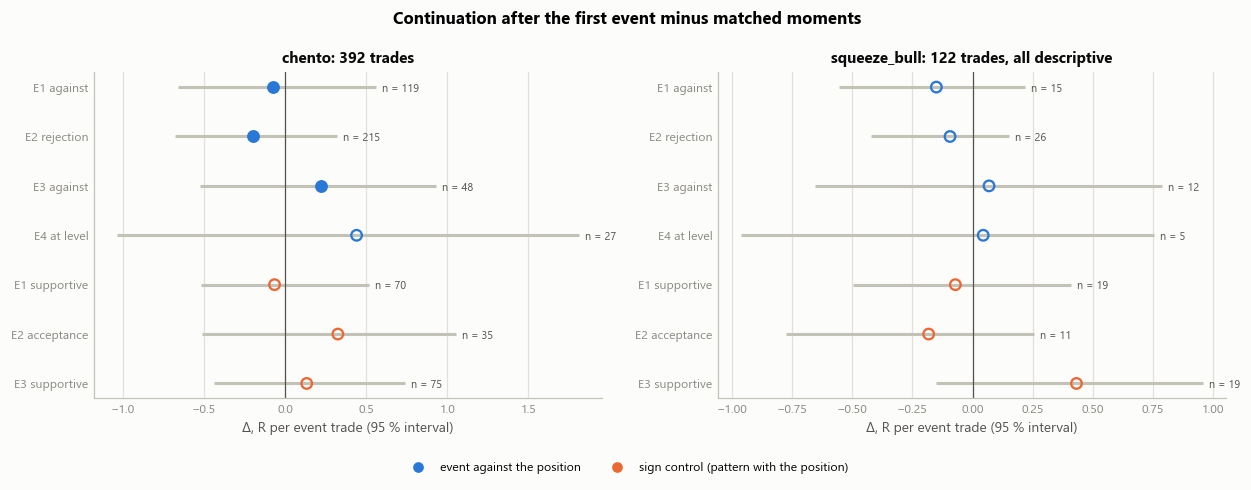

,n,delta,ci95_lo,ci95_hi,p_one_sided,holm_p,first_half,second_half,time-only placebo,no-time-exit walk,classification
chento:E1_against,119,-0.073397,-0.659213,0.562929,0.413659,0.827317,0.80166,-0.963285,0.22176,0.208586,UNDETERMINED
chento:E2_rejection,215,-0.197912,-0.678567,0.317078,0.229677,0.689031,0.25224,-0.652272,0.046039,-0.170259,UNDETERMINED
chento:E3_against,48,0.22183,-0.523405,0.930974,0.738926,0.827317,0.839242,-0.395583,0.332577,0.486039,UNDETERMINED
chento:E4_at_level,27,0.440843,-1.037639,1.810401,0.749625,None,1.778286,-0.999479,0.517196,1.457182,DESCRIPTIVE
chento:E1_supportive,70,-0.06504,-0.517821,0.51649,0.407159,None,0.405022,-0.535103,0.046759,-0.782091,sign control
chento:E2_acceptance,35,0.325454,-0.510617,1.054315,0.810719,None,1.432067,-0.846255,0.53967,0.564771,sign control
chento:E3_supportive,75,0.133369,-0.440812,0.737745,0.672433,None,0.275945,-0.01306,0.149926,-0.081605,sign control
squeeze_bull:E1_against,15,-0.150392,-0.556082,0.219212,0.220178,None,-0.095763,-0.212825,-0.110563,-0.267516,DESCRIPTIVE
squeeze_bull:E2_rejection,26,-0.093524,-0.421136,0.1529,0.252575,None,-0.244528,0.05748,-0.077087,-0.254108,DESCRIPTIVE
squeeze_bull:E3_against,12,0.068405,-0.655,0.786815,0.5699,None,-0.436641,0.573451,0.041342,-0.05352,DESCRIPTIVE


In [5]:
def forest(ax, pop, title):
    keys = [k for k in M.KINDS if REP["tests"][f"{pop}:{k}"]["delta"].get("n")]
    y = np.arange(len(keys))[::-1]
    for yi, k in zip(y, keys):
        t = REP["tests"][f"{pop}:{k}"]; d = t["delta"]
        colour = SERIES[0] if k in M.PRIMARY else SERIES[1]
        ax.hlines(yi, d["ci95"][0], d["ci95"][1], color=AXIS, linewidth=2)
        ax.scatter([d["mean"]], [yi], s=48, zorder=3, facecolors=colour if t["in_family"] else "none",
                   edgecolors=colour, linewidths=1.5)
        ax.annotate(f"n = {d['n']}", (d["ci95"][1], yi), xytext=(4, -3), textcoords="offset points", fontsize=7, color=INK2)
    ax.axvline(0, color=INK2, linewidth=0.8)
    ax.set_yticks(y); ax.set_yticklabels([k.replace("_", " ") for k in keys])
    style(ax, grid_axis="x"); ax.set_xlabel("Δ, R per event trade (95 % interval)"); ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
forest(axes[0], "chento", "chento: 392 trades")
forest(axes[1], "squeeze_bull", "squeeze_bull: 122 trades, all descriptive")
handles = [Line2D([], [], marker="o", linestyle="", color=SERIES[0], label="event against the position"),
           Line2D([], [], marker="o", linestyle="", color=SERIES[1], label="sign control (pattern with the position)")]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Continuation after the first event minus matched moments", fontsize=11, fontweight="bold")
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.show()
T = pd.DataFrame({k: {"n": t["delta"].get("n"), "delta": t["delta"].get("mean"),
                      "ci95_lo": t["delta"]["ci95"][0] if t["delta"].get("n") else None,
                      "ci95_hi": t["delta"]["ci95"][1] if t["delta"].get("n") else None,
                      "p_one_sided": t["delta"].get("p_one_sided_less"), "holm_p": t.get("holm_p"),
                      "first_half": t["delta"].get("first_half"), "second_half": t["delta"].get("second_half"),
                      "time-only placebo": t["secondary_time_only"].get("mean"),
                      "no-time-exit walk": t["secondary_no_time_exit"].get("mean"),
                      "classification": t.get("classification", "sign control")} for k, t in REP["tests"].items()}).T
T

## 5. What holding after an event was worth, in absolute terms

For an exit, what matters is the continuation value itself. On chento, holding after every event still returned +0.5 to
+1.0 R per event trade. Exiting at the first absorption would have cost 0.24 R per trade overall, and at the first
rejection 0.36 R (price only; the exit leg is paid either way). On squeeze_bull, holding after absorption or rejection was
worth about zero, and so was holding after acceptance, the opposite of a rejection.

,population,event,event trades,mean CV after the event,mean matched placebo,"exit at first event minus shipped, R per trade"
0,chento,E1_against,122,0.782,0.853,-0.243
1,chento,E2_rejection,219,0.641,0.871,-0.358
2,chento,E3_against,51,0.721,0.511,-0.094
3,chento,E4_at_level,27,0.971,0.530,-0.067
4,chento,E1_supportive,71,0.558,0.625,-0.101
5,chento,E2_acceptance,35,1.038,0.712,-0.093
6,chento,E3_supportive,75,0.517,0.384,-0.099
7,squeeze_bull,E1_against,15,0.018,0.168,-0.002
8,squeeze_bull,E2_rejection,26,0.020,0.113,-0.004
9,squeeze_bull,E3_against,12,0.165,0.096,-0.016


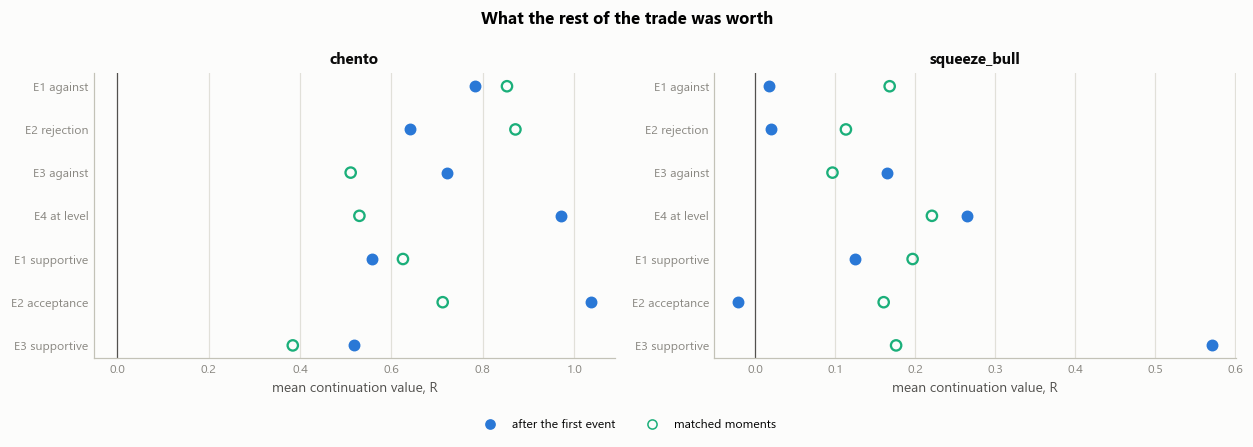

In [6]:
rows = []
for p in ("chento", "squeeze_bull"):
    N = len(pops[p])
    for k in M.KINDS:
        e = events[(events["pop"] == p) & (events["kind"] == k)]
        if not len(e):
            continue
        rows.append({"population": p, "event": k, "event trades": len(e), "mean CV after the event": e["cv"].mean(),
                     "mean matched placebo": REP["tests"][f"{p}:{k}"]["mean_placebo"],
                     "exit at first event minus shipped, R per trade": -e["cv"].sum() / N})
A = pd.DataFrame(rows)
display(A.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for ax, p in zip(axes, ("chento", "squeeze_bull")):
    a = A[A.population == p].reset_index(drop=True)
    y = np.arange(len(a))[::-1]
    ax.scatter(a["mean CV after the event"], y, s=46, color=SERIES[0], zorder=3)
    ax.scatter(a["mean matched placebo"], y, s=46, facecolors="none", edgecolors=SERIES[2], linewidths=1.5, zorder=3)
    ax.axvline(0, color=INK2, linewidth=0.8)
    ax.set_yticks(y); ax.set_yticklabels([k.replace("_", " ") for k in a["event"]])
    style(ax, grid_axis="x"); ax.set_xlabel("mean continuation value, R"); ax.set_title(p, fontsize=10)
handles = [Line2D([], [], marker="o", linestyle="", color=SERIES[0], label="after the first event"),
           Line2D([], [], marker="o", linestyle="", markerfacecolor="none", markeredgecolor=SERIES[2], label="matched moments")]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("What the rest of the trade was worth", fontsize=11, fontweight="bold")
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.show()

## 6. Halves, years, and an exploratory era-matched control

Every chento event and every sign control was positive in the first half and negative in the second. The frozen placebo
draws controls from all years. A period in which holding paid more for every trade (2021–2023, where chento's
no-time-stop gain sat) therefore shows up in whichever events fell in it. An exploratory control added after the verdict
(`micro_explore.py`, not pre-registered) keeps only controls entering within ±365 days of the event trade. It removes
part of the swing, but no interval moves away from zero.

In [7]:
rows = []
for k, s in ERA["tests"].items():
    f = REP["tests"][k]["delta"]
    rows.append({"test": k, "all years Δ": f["mean"], "halves, all years": f"{f['first_half']:+.2f} / {f['second_half']:+.2f}",
                 "era-matched Δ": s["mean"], "era 95 % lo": s["ci95"][0], "era 95 % hi": s["ci95"][1],
                 "halves, era-matched": f"{s['first_half']:+.2f} / {s['second_half']:+.2f}", "n, era-matched": s["n"]})
display(pd.DataFrame(rows).set_index("test").round(3))
pd.DataFrame({k.split(":")[1]: {y: v["mean"] for y, v in REP["tests"][k]["delta"]["by_year"].items()}
              for k in REP["tests"] if k.startswith("chento:") and REP["tests"][k]["delta"].get("n")}).round(2)

,all years Δ,"halves, all years",era-matched Δ,era 95 % lo,era 95 % hi,"halves, era-matched","n, era-matched"
test,,,,,,,
chento:E1_against,-0.073,+0.80 / -0.96,-0.144,-0.741,0.475,+0.51 / -0.80,98
chento:E2_rejection,-0.198,+0.25 / -0.65,-0.159,-0.666,0.368,-0.08 / -0.24,193
chento:E3_against,0.222,+0.84 / -0.40,0.131,-0.578,0.858,+0.44 / -0.18,44
chento:E4_at_level,0.441,+1.78 / -1.00,0.580,-0.729,1.802,+1.60 / -0.52,27
chento:E1_supportive,-0.065,+0.41 / -0.54,0.005,-0.461,0.588,+0.31 / -0.31,65
chento:E2_acceptance,0.325,+1.43 / -0.85,0.388,-0.428,1.115,+1.28 / -0.51,32
chento:E3_supportive,0.133,+0.28 / -0.01,0.152,-0.448,0.769,-0.07 / +0.37,68
squeeze_bull:E1_against,-0.150,-0.10 / -0.21,-0.140,-0.519,0.201,-0.34 / +0.10,13
squeeze_bull:E2_rejection,-0.094,-0.24 / +0.06,-0.101,-0.467,0.180,-0.37 / +0.17,22


,E1_against,E2_rejection,E3_against,E4_at_level,E1_supportive,E2_acceptance,E3_supportive
2021,0.12,0.37,NaN,-0.45,-0.30,0.22,NaN
2022,0.22,-0.27,NaN,0.08,1.17,1.53,NaN
2023,1.37,0.98,1.20,4.06,0.96,2.15,0.67
2024,-0.14,-0.41,0.44,3.25,-0.39,-0.16,0.18
2025,-1.13,-1.08,-0.94,-1.91,-0.25,-0.01,-0.19
2026,-0.80,-0.26,-0.56,-0.62,-0.27,-1.94,0.10


## Conclusion

- **Nothing promoted.** On chento, the only population with enough events, none of three events carries information
  this sample can detect (Holm-adjusted p 0.69–0.83): absorption against the position, rejection of the prior-day
  extreme, and an order book tilted against the position. Their sign controls behave the same way, and holding after
  every event still paid.
- **short_squeeze almost never meets these events** (0–2 of 71 trades). Its trades resolve in about an hour, before an
  extreme flow or book reading appears, so exits keyed on them could not change it.
- **squeeze_bull meets them on 4–21 % of trades**, too few to test. Holding after them was worth about zero, but so was
  holding after their opposites.
- **What this does not rule out.** Information smaller than about 0.3–0.6 R per event trade on chento, and anything the
  public archive cannot see: sub-minute order flow, live depth, individual prints. By the pre-registration this closes
  the line for these events at this resolution.